<a href="https://colab.research.google.com/github/giovannaloro/AN2DL_PROJECT_2024_M2G/blob/main/DL_HW_%7C_Mershad's_Draft_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Set Up the Environment for TPU Training in Colab

To avoid serialization issues with Codabench, we need to install specific versions of TensorFlow and Keras, as described in the instructions you provided. Let’s add the necessary cells at the start of the notebook.

In [1]:
# Cell 1: Specify required library versions in requirements.txt
%%writefile requirements.txt
tensorflow==2.17.0
keras==3.4.1


Writing requirements.txt


In [2]:

# Cell 2: Install the libraries specified in the requirements.txt file
!pip install -r requirements.txt


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.8/47.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.3/601.3 MB 631.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 103.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.3/381.3 kB 23.1 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.2.0
    Uninstalling ml-dtypes-0.2.0:
      Successfully uninstalled ml-dtypes-0.2.0
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.15.2
    Uninstalling tensorboard-2.15.2:
      Successfully uninstalled tensorboard-2.15.2
  Attempting uninstall: keras
    Found existing installation: keras 2.15.0
    Uninstalling keras-2.15.0:
      Successfully uninstalled keras-2.15.0
  Attempting uninstall: tensorflow


In [3]:

# Cell 3: Import the libraries with the proper versions and aliases
import numpy as np
import os

import tensorflow as tf
import keras as tfk  # Import keras instead of tensorflow.keras
from keras.layers import Input, Dense, Dropout, Lambda
from keras import layers as tfkl

# Print the versions to ensure everything is correct
print(f"Tensorflow version -> {tf.__version__}")
print(f"Keras version -> {tfk.__version__}")


Tensorflow version -> 2.17.0
Keras version -> 3.4.1


#Import Libraries

In [4]:
import numpy as np
import os
import random

import tensorflow as tf
import keras as tfk
from keras import layers as tfkl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from sklearn.utils import class_weight
from sklearn.utils import resample

from keras.applications import EfficientNetB0
from keras.models import Model
from keras.layers import GlobalAveragePooling2D, Dense, Dropout


# Load the Data
The dataset is provided as an .npz file. Let’s load it:

In [ ]:
from google.colab import drive
drive.mount('/gdrive')
%cd /gdrive/My Drive/[2024-2025] AN2DL HOMEWORK 1

Mounted at /gdrive
/gdrive/.shortcut-targets-by-id/117Cy5jmRvw7kUjsl1Y2WzOeI_SAmudjh/[2024-2025] AN2DL HOMEWORK 1


In [ ]:
# Load the dataset
data = np.load('training_set.npz')  # Replace with correct path
X = data['images']
y = data['labels']

# Print the shapes to verify
print(f"Images shape: {X.shape}")
print(f"Labels shape: {y.shape}")


Images shape: (13759, 96, 96, 3)
Labels shape: (13759, 1)


##Display Images

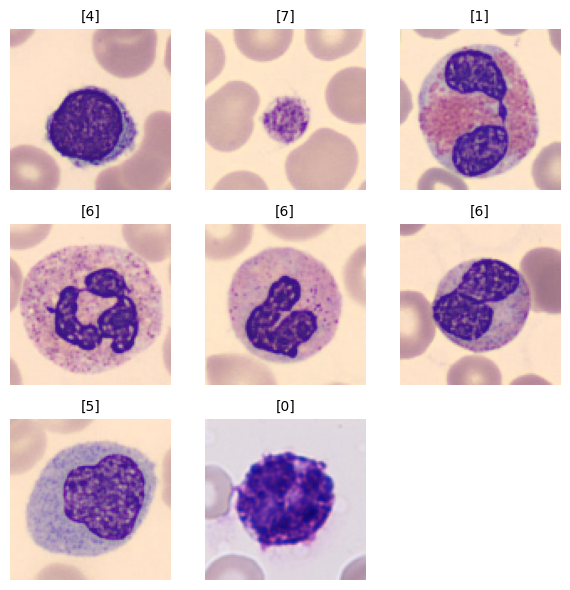

In [ ]:
def display_images(X, y, num_img):
    """
    Display images in a square grid, handling normalization if necessary.

    Parameters:
        X (array-like): Array of images (can be normalized between [0, 1] or in the range [0, 255]).
        y (array-like): Array of labels corresponding to the images.
        num_img (int): Number of images to display (default is 100).
    """
    grid_size = int(np.ceil(np.sqrt(num_img)))  # Calculate grid size for a square layout
    random_indices = random.sample(range(len(X)), num_img)  # Randomly select images

    # Create subplots
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(6, 6))

    for i, idx in enumerate(random_indices):
        ax = axes[i // grid_size, i % grid_size]  # Locate subplot

        # Handle normalization: convert [0, 1] range to [0, 255] if necessary
        img = X[idx]
        if img.max() <= 1.0:
            img = np.clip(img, 0, 1) * 255
        else:
            img = np.clip(img, 0, 255)

        # Display image
        ax.imshow(img.astype(np.uint8))
        ax.set_title(f'{y[idx]}', fontsize=10)  # Set title with smaller font size
        ax.axis('off')  # Turn off axis

    # Turn off unused subplots
    for j in range(num_img, grid_size * grid_size):
        fig.delaxes(axes[j // grid_size, j % grid_size])

    plt.tight_layout()
    plt.show()

display_images(X, y, 8)

<ipython-input-36-385ede48e15e>:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_label = int(y[idx])  # Convert the label to an integer scalar


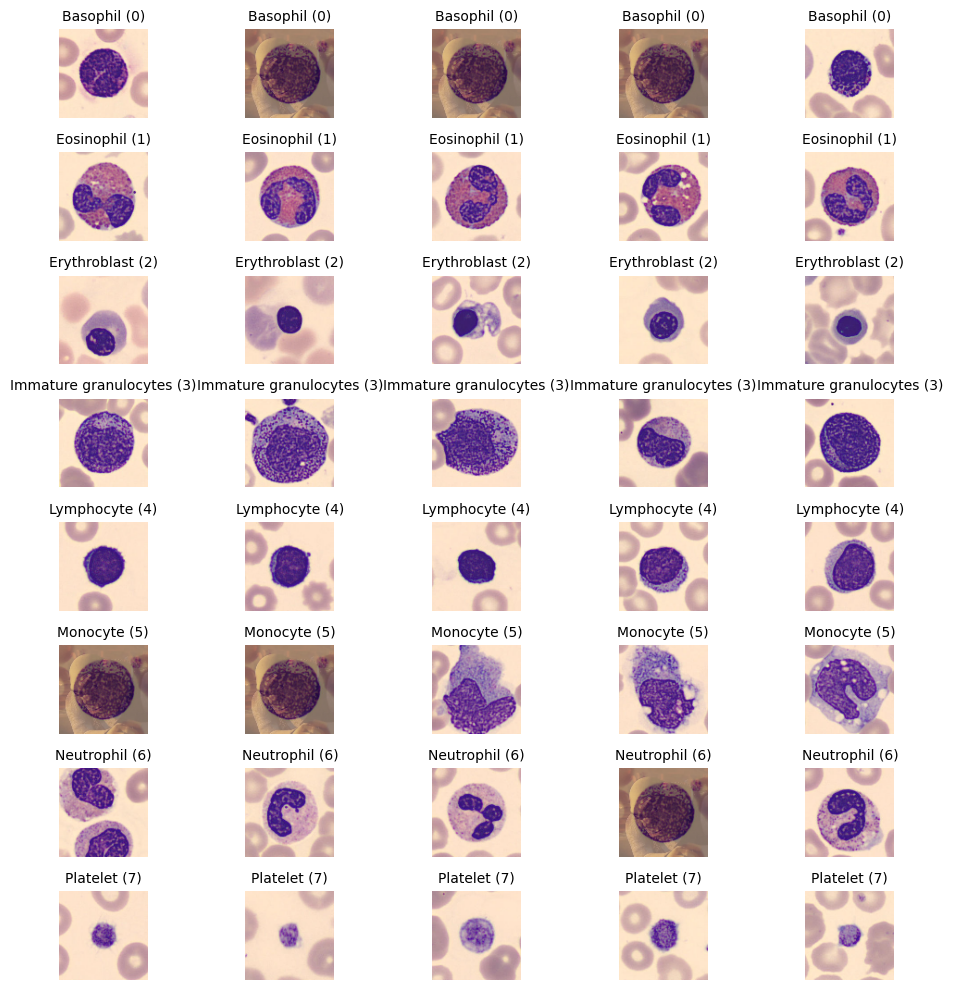

In [ ]:
# Class labels dictionary for mapping numerical labels to their names
class_labels = {
    0: 'Basophil',
    1: 'Eosinophil',
    2: 'Erythroblast',
    3: 'Immature granulocytes',
    4: 'Lymphocyte',
    5: 'Monocyte',
    6: 'Neutrophil',
    7: 'Platelet'
}

def display_images(X, y):
    """
    Display 5 random images for each class in a grid.

    Parameters:
        X (array-like): Array of images (can be normalized between [0, 1] or in the range [0, 255]).
        y (array-like): Array of labels corresponding to the images.
    """
    num_samples_per_class = 5
    num_classes = len(class_labels)
    selected_indices = []

    # Collect random 5 samples for each class
    for class_num in range(num_classes):
        class_indices = np.where(y == class_num)[0]
        if len(class_indices) >= num_samples_per_class:
            random_indices = np.random.choice(class_indices, num_samples_per_class, replace=False)
            selected_indices.extend(random_indices)
        else:
            selected_indices.extend(class_indices)  # If fewer than 5, add all available

    # Plotting the selected images
    fig, axes = plt.subplots(num_classes, num_samples_per_class, figsize=(10, 10))

    for i, idx in enumerate(selected_indices):
        ax = axes[i // num_samples_per_class, i % num_samples_per_class]

        # Handle normalization: convert [0, 1] range to [0, 255] if necessary
        img = X[idx]
        if img.max() <= 1.0:
            img = np.clip(img, 0, 1) * 255
        else:
            img = np.clip(img, 0, 255)

        # Display image
        ax.imshow(img.astype(np.uint8))
        class_label = int(y[idx])  # Convert the label to an integer scalar
        ax.set_title(f'{class_labels[class_label]} ({class_label})', fontsize=10)
        ax.axis('off')  # Turn off axis

    plt.tight_layout()
    plt.show()

# Call the function to display random images
display_images(X, y)

#Preprocess the Data


##Exploratory Data Analysis (EDA)
Class Distribution Visualization
First, we want to check the class distribution to see if there is any imbalance:

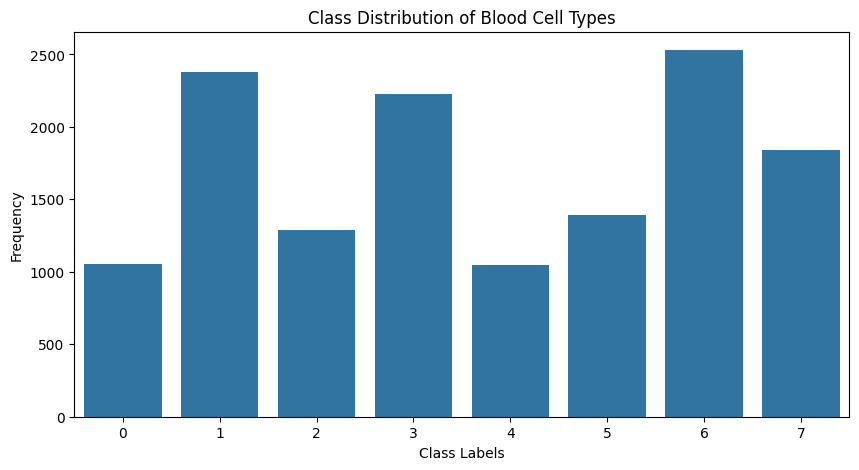

Class 0: 1052 samples
Class 1: 2381 samples
Class 2: 1285 samples
Class 3: 2226 samples
Class 4: 1049 samples
Class 5: 1393 samples
Class 6: 2530 samples
Class 7: 1843 samples


In [ ]:
# Plotting class distribution
unique, counts = np.unique(y, return_counts=True)
plt.figure(figsize=(10, 5))
sns.barplot(x=unique, y=counts)
plt.xlabel("Class Labels")
plt.ylabel("Frequency")
plt.title("Class Distribution of Blood Cell Types")
plt.show()

# Printing the counts for clarity
for i, count in enumerate(counts):
    print(f"Class {i}: {count} samples")


##Undersampling to Remove Outliers

The undersampling method will help bring the larger classes to a balanced state by reducing their count to match the minority classes. This indirectly removes potential outliers by taking a subset of the most frequent classes, leaving only representative samples.

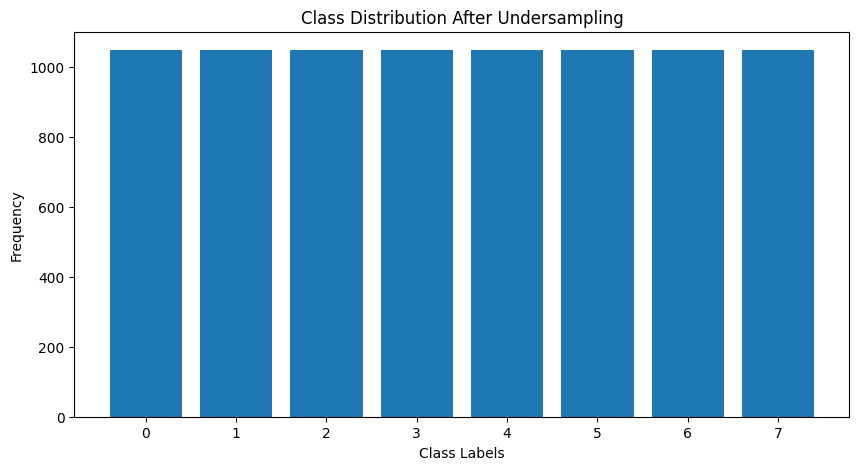

In [ ]:

def undersample_data(X, y):
    """
    Apply undersampling to balance the dataset based on the minority class size.

    Parameters:
        X (array-like): Array of images, shape (n_samples, 96, 96, 3).
        y (array-like): Array of labels corresponding to the images, shape (n_samples,).

    Returns:
        X_balanced (array-like): Undersampled dataset of images.
        y_balanced (array-like): Labels for the balanced dataset.
    """

    # Split the data based on class labels
    data_per_class = {}
    for class_label in np.unique(y):
        indices = np.where(y == class_label)[0]  # Get indices of samples belonging to the class
        X_class = X[indices]
        y_class = y[indices]
        data_per_class[class_label] = (X_class, y_class)

    # Find the minimum count of any class (to balance the dataset)
    min_count = min([len(data_per_class[key][1]) for key in data_per_class])

    # Undersample each class to match the min count
    X_resampled = []
    y_resampled = []

    for key in data_per_class:
        X_class, y_class = data_per_class[key]
        X_downsampled, y_downsampled = resample(X_class, y_class,
                                                replace=False,
                                                n_samples=min_count,
                                                random_state=42)
        X_resampled.append(X_downsampled)
        y_resampled.append(y_downsampled)

    # Concatenate all the undersampled data
    X_balanced = np.concatenate(X_resampled, axis=0)
    y_balanced = np.concatenate(y_resampled, axis=0)

    return X_balanced, y_balanced

# Use the function to undersample the dataset
X_balanced, y_balanced = undersample_data(X, y)

# Plot the new class distribution
unique, counts = np.unique(y_balanced, return_counts=True)
plt.figure(figsize=(10, 5))
plt.bar(unique, counts)
plt.xlabel("Class Labels")
plt.ylabel("Frequency")
plt.title("Class Distribution After Undersampling")
plt.show()

## Data Augmentation

After undersampling, the dataset may have become significantly smaller. To make up for the reduction in data size and to introduce variability, we will use data augmentation. Data augmentation involves applying random transformations to the images, such as rotations, flips, shifts, etc., to generate more diverse data from the existing examples.

In [ ]:
from keras.preprocessing.image import ImageDataGenerator

# Initialize the ImageDataGenerator for data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,            # Random rotations up to 20 degrees
    width_shift_range=0.2,        # Random horizontal shifts
    height_shift_range=0.2,       # Random vertical shifts
    shear_range=0.15,             # Shear transformations
    zoom_range=0.2,               # Random zoom
    horizontal_flip=True,         # Random horizontal flipping
    fill_mode='nearest'           # Fill mode for transformations
)

# Fit the data generator to your undersampled dataset (X_balanced)
datagen.fit(X_balanced)

# Example to visualize a few augmented images from a specific class
import matplotlib.pyplot as plt

def visualize_augmentation(datagen, X_sample):
    """
    Visualizes a few augmented versions of the given input image.

    Parameters:
        datagen: ImageDataGenerator for data augmentation.
        X_sample (array-like): A sample image for augmentation visualization.
    """
    plt.figure(figsize=(10, 10))
    for i, augmented_img in enumerate(datagen.flow(X_sample[np.newaxis], batch_size=1)):
        if i >= 9:  # Display 9 images
            break
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_img[0].astype('uint8'))
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Visualize the augmented version of a random image from X_balanced
visualize_augmentation(datagen, X_balanced[0])


##Normaliziation
We need to normalize the data, and we should also split it into training and validation sets for evaluation:

In [ ]:
# Normalizing the images
X = X_balanced / 255.0

# Checking basic statistics of the images
print(f"Minimum pixel value: {X.min()}")
print(f"Maximum pixel value: {X.max()}")

# Check the shape of X and y
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Minimum pixel value: 0.0
Maximum pixel value: 1.0
Shape of X: (8392, 96, 96, 3)
Shape of y: (13759, 8)


In [ ]:
# Convert labels to categorical
y = to_categorical(y_balanced, num_classes=8)

# Check the shape of X and y
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (8392, 96, 96, 3)
Shape of y: (8392, 8)


##Train-Test Split

In [ ]:

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y,
                                                  test_size=0.2,
                                                  random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")


Training data shape: (6713, 96, 96, 3)
Validation data shape: (1679, 96, 96, 3)


#Build the Model
Let's build a simple convolutional neural network (CNN) to classify these blood cell images:

In [ ]:
def create_model(input_shape=(96, 96, 3)):
    inputs = tfk.Input(shape=input_shape)
    x = tfkl.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = tfkl.MaxPooling2D((2, 2))(x)
    x = tfkl.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = tfkl.MaxPooling2D((2, 2))(x)
    x = tfkl.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = tfkl.MaxPooling2D((2, 2))(x)

    x = tfkl.Flatten()(x)
    x = tfkl.Dense(128, activation='relu')(x)
    x = tfkl.Dropout(0.5)(x)
    outputs = tfkl.Dense(8, activation='softmax')(x)

    model = tfk.Model(inputs, outputs)
    return model

model = create_model()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 96, 96, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 48, 48, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 24, 24, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 18432)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       2,359,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │           1,032 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,453,704 (9.36 MB)

 Trainable params: 2,453,704 (9.36 MB)

 Non-trainable params: 0 (0.00 B)

##Pre-trained Model Selection and Transfer Learning
We will use EfficientNetB0 as a pre-trained model because it is a powerful image classification network known for efficiency and high performance. We'll leverage transfer learning to fine-tune this network for our specific task.

In [ ]:

# Using a pre-trained EfficientNetB0 as the base model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(96, 96, 3))

# Freezing the base model layers so that we can train only the top layers initially
base_model.trainable = False

# Adding custom layers on top of the pre-trained model
inputs = tfk.Input(shape=(96, 96, 3))
x = base_model(inputs, training=False)  # Inference mode for base model layers
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
outputs = Dense(8, activation='softmax')(x)

model = tfk.Model(inputs, outputs)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 3, 3, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 8)                   │          10,248 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,059,819 (15.49 MB)

 Trainable params: 10,248 (40.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

# Compile the Model
We will compile the model using appropriate hyperparameters for optimization and loss functions:

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
# Compile the model:

model.compile(optimizer=tfk.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

In [ ]:
# Fine-tune the base model by unfreezing some layers if needed
base_model.trainable = True
model.compile(optimizer=tfk.optimizers.Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#Train the Model
Now that the model is ready. Let’s start training:

In [ ]:
# Set training parameters
batch_size = 32
epochs = 20

# Train the model
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    batch_size=batch_size,
                    epochs=epochs)


Epoch 1/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 27s 73ms/step - accuracy: 0.3493 - loss: 1.7100 - val_accuracy: 0.6646 - val_loss: 0.8491
Epoch 2/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.6493 - loss: 0.9223 - val_accuracy: 0.7594 - val_loss: 0.6262
Epoch 3/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.7136 - loss: 0.7423 - val_accuracy: 0.7718 - val_loss: 0.5763
Epoch 4/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.7444 - loss: 0.6682 - val_accuracy: 0.7918 - val_loss: 0.5653
Epoch 5/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 22s 63ms/step - accuracy: 0.7499 - loss: 0.6427 - val_accuracy: 0.8172 - val_loss: 0.4884
Epoch 6/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 22s 65ms/step - accuracy: 0.7676 - loss: 0.6053 - val_accuracy: 0.8020 - val_loss: 0.5082
Epoch 7/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.7907 - loss: 0.5494 - val_accuracy: 0.8227 - val_loss: 0.4540
Epoch 8/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.7941 - loss: 0.5290 - 

In [ ]:
# Train the model
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=20,
                    batch_size=32)


In [ ]:


# Continue training for additional epochs
history_finetune = model.fit(X_train, y_train,
                             validation_data=(X_val, y_val),
                             epochs=20,
                             batch_size=64)

Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 31s 212ms/step - accuracy: 0.1214 - loss: 2.1299 - val_accuracy: 0.1286 - val_loss: 2.0863
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 19s 185ms/step - accuracy: 0.1249 - loss: 2.1169 - val_accuracy: 0.1197 - val_loss: 2.0941
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 187ms/step - accuracy: 0.1323 - loss: 2.1176 - val_accuracy: 0.1286 - val_loss: 2.1009
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 187ms/step - accuracy: 0.1130 - loss: 2.1230 - val_accuracy: 0.1197 - val_loss: 2.1001
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 193ms/step - accuracy: 0.1206 - loss: 2.1121 - val_accuracy: 0.1239 - val_loss: 2.0896
Epoch 6/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 192ms/step - accuracy: 0.1260 - loss: 2.1081 - val_accuracy: 0.1304 - val_loss: 2.0898
Epoch 7/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 191ms/step - accuracy: 0.1280 - loss: 2.1087 - val_accuracy: 0.1286 - val_loss: 2.0964
Epoch 8/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 191ms/step - accuracy: 0.1262 - loss: 2

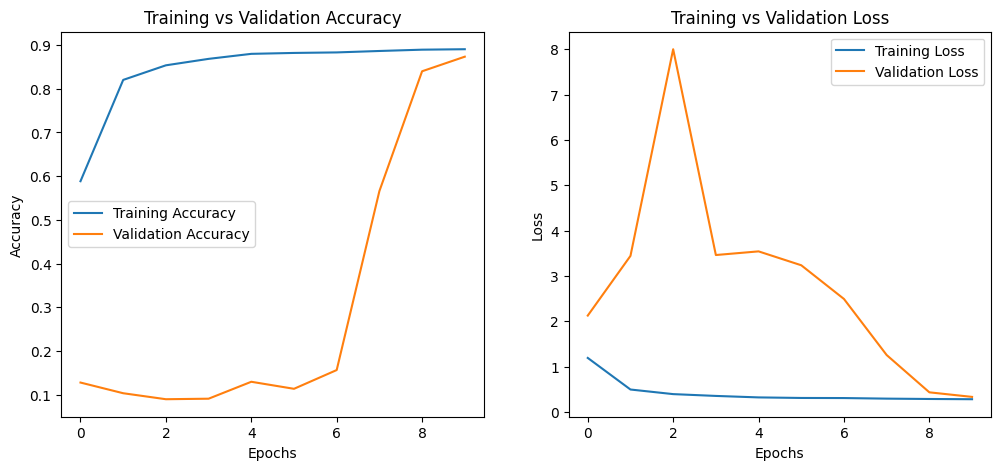

In [ ]:
# Plot the training history
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history_finetune.history['accuracy'], label='Training Accuracy')
plt.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history_finetune.history['loss'], label='Training Loss')
plt.plot(history_finetune.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()


#Evaluate and Save the Model
After training, evaluate the model on the validation set and save it to submit to Codabench:

In [ ]:
# Evaluate the model
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")



53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.8710 - loss: 0.3503
Validation Loss: 0.33008885383605957
Validation Accuracy: 0.8731387853622437


##Exploratory Visualizations
###Training History Plot
Plot the training and validation loss/accuracy to analyze the model's learning over epochs:

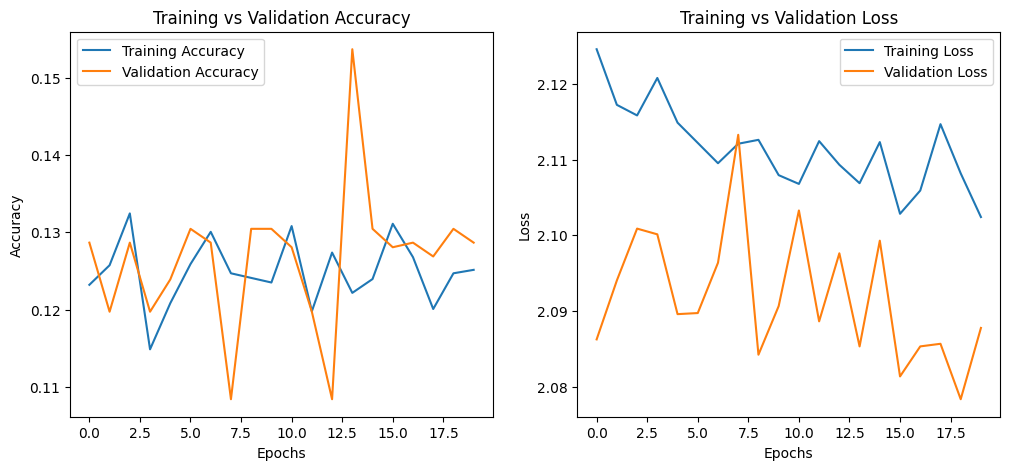

In [ ]:
# Plot the training history
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()


#Export Your Trained Model

In [ ]:
model.save("blood_cell_effnet_model.keras")


NameError: name 'model' is not defined

##Create the model.py File
The model.py file should define a Model class with an __init__ method (for loading the model) and a predict method to perform predictions.

Here is an implementation of model.py:

In [ ]:
# file: model.py

class Model:
    def __init__(self):
        """Initializes the model's internal state by loading the pre-trained model."""
        self.model = tfk.models.load_model("blood_cell_effnet_model.keras")

    def predict(self, X):
        """Returns a numpy array of labels for the given input X.

        Args:
            X: A numpy array of shape (n_samples, 96, 96, 3) representing the test data.

        Returns:
            A numpy array of shape (n_samples,) containing the predicted class values.
        """
        predictions = self.model.predict(X)
        # Convert one-hot predictions to class labels
        predicted_labels = np.argmax(predictions, axis=1)
        return predicted_labels


##Create the .zip File for Submission
Your .zip file should contain:

model.py - The script for prediction, containing the Model class.
blood_cell_effnet_model.keras - The saved model file to load and use in model.py.
Steps to create the .zip file:

Save the model.py script: Save the Python script provided above as model.py.

Ensure your model file is in the same directory: Make sure that blood_cell_effnet_model.keras is in the same directory as model.py.

Create the .zip file:

In your local system or Colab, use the following commands to create the .zip file:

In [ ]:
from datetime import datetime
filename = f'submission_{datetime.now().strftime("%y%m%d_%H%M%S")}.zip'

# Add files to the zip command if needed
!zip {filename} model.py weights.keras

from google.colab import files
files.download(filename)